In [1]:
from mpramnist.Reddy2023 import ReddyDataset
from mpramnist.Reddy2023 import LitModel_Reddy_Reg
from mpramnist.Reddy2023 import LitModel_Reddy_Clas

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

from mpramnist import transforms as t

import torch.nn as nn
import torch.utils.data as data
import lightning.pytorch as L

BATCH_SIZE = 32
NUM_WORKERS = 103

# Regressions Task

In [2]:
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(),])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "regression"
cell_types = ["JURKAT", "K562", "THP1"]

train_dataset = ReddyDataset(task=task,cell_type=cell_types,split="train",transform=train_transform,root="../data/",)
val_dataset = ReddyDataset(task=task,cell_type=cell_types,split="val",transform=val_test_transform,root="../data/",)
test_dataset = ReddyDataset(task=task,cell_type=cell_types,split="test",transform=val_test_transform,root="../data/",)

print(len(train_dataset),len(val_dataset),len(test_dataset))

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

in_channels = len(train_dataset[0][0])
out_channels = len(cell_types)

100%|██████████| 4.02M/4.02M [00:01<00:00, 2.10MB/s]
100%|██████████| 461k/461k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.09M/1.09M [00:00<00:00, 1.52MB/s]

12335 1416 3353


In [5]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=out_channels,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Reddy_Reg(model=model,cell_types=cell_types,loss=nn.MSELoss(),weight_decay=1e-1,lr=1e-2,print_each=10,)
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[1],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly

Epoch 0: 100%|██████████| 386/386 [00:35<00:00, 10.75it/s, v_num=0, train_loss_step=0.733, val_loss=0.999, val_JURKAT_pearson=0.463, val_K562_pearson=0.443, val_THP1_pearson=0.431, val_pearson=0.446, train_loss_epoch=1.130]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 386/386 [00:36<00:00, 10.71it/s, v_num=0, train_loss_step=0.733, val_loss=0.999, val_JURKAT_pearson=0.463, val_K562_pearson=0.443, val_THP1_pearson=0.431, val_pearson=0.446, train_loss_epoch=1.130]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 105/105 [00:01<00:00, 65.53it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_JURKAT_pearson      0.46612751483917236
    test_K562_pearson       0.4479755163192749
    test_THP1_pearson       0.39108750224113464
        test_loss           0.9931444525718689
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.9931444525718689,
  'test_JURKAT_pearson': 0.46612751483917236,
  'test_K562_pearson': 0.4479755163192749,
  'test_THP1_pearson': 0.39108750224113464}]

# Classification Task

In [2]:
train_transform = t.Compose([t.ReverseComplement(0.5), t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "classification"
cell_types = ["JURKAT", "K562", "THP1"]

train_dataset = ReddyDataset(task=task,cell_type=cell_types,split="train",transform=train_transform,root="../data/",)
val_dataset = ReddyDataset(task=task,cell_type=cell_types,split="val",transform=val_test_transform,root="../data/",)
test_dataset = ReddyDataset(task=task,cell_type=cell_types,split="test",transform=val_test_transform,root="../data/",)

print(len(train_dataset),len(val_dataset),len(test_dataset))

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

in_channels = len(train_dataset[0][0])
out_channels = len(cell_types)

12335 1416 3353


In [3]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=out_channels,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Reddy_Clas(model=model,n_labels=out_channels,loss=nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-2,print_each=10,)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly

Epoch 0: 100%|██████████| 386/386 [00:36<00:00, 10.71it/s, v_num=2, val_loss=0.617]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 386/386 [00:36<00:00, 10.64it/s, v_num=2, val_loss=0.617]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 105/105 [00:11<00:00,  8.78it/s]
----------------------------------------------------------------------------------------------------
| Test Acc: 0.6613977551460266 | Test AUROC: 0.724600076675415 | Test AUPR: 0.7212427854537964 |
| Test Precision: 0.6508075594902039 | Test Recall: 0.6978211998939514 | Test F1: 0.6734797358512878 
----------------------------------------------------------------------------------------------------



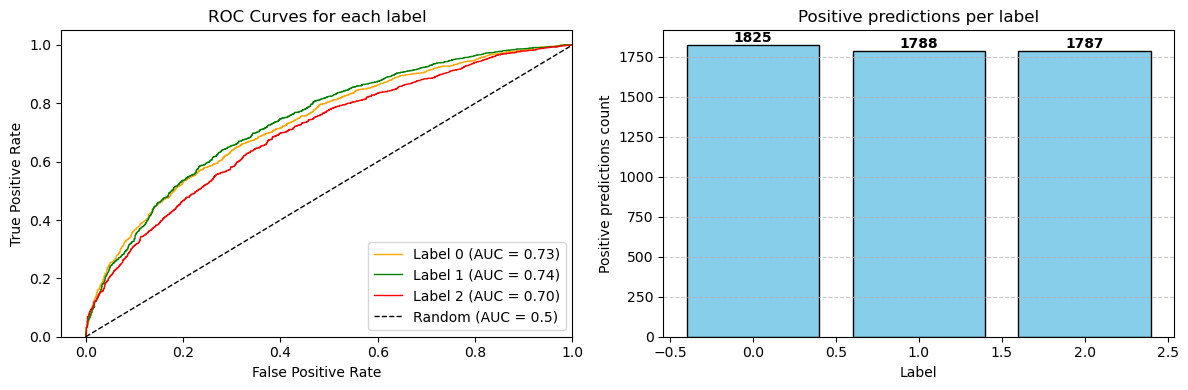

Testing DataLoader 0: 100%|██████████| 105/105 [00:13<00:00,  8.00it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.6118317246437073
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6118317246437073}]

In [4]:
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[1],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)